<a href="https://colab.research.google.com/github/madhumitha006/Madhumitha-Codeboosters-internship-2026/blob/main/day_2_Database_SQL_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
#suppresses non-critical warning messages that clutter output
print("All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.sqlite_version}")

All libraries imported successfully!
pandas version: 2.2.2
sqlite3 version: 3.37.2


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows:")
print(df.head(3))

Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2                     78      Delh

In [27]:
conn=sqlite3.connect('college.db')
#'conn'=our connection to the database
#'college.db'=the file that will be created in Colab's filesystem
cursor=conn.cursor()
df.to_sql(
    'Titanic',
    conn,
    if_exists='replace',
    index=False
)

30

In [31]:
cursor.execute("SELECT COUNT(*) FROM Titanic")
count = cursor.fetchone()[0]
print("Database 'college.db' created successfully!")
print(f"Table 'Titanic' has {count} rows")

Database 'college.db' created successfully!
Table 'Titanic' has 30 rows


In [32]:
cursor.execute("PRAGMA table_info(Titanic)")
columns_info = cursor.fetchall()
print("Table structure of 'Titanic':")
print(f"{'Column Name':<25}{'Data Type':<12}")
print("-" * 30)
for col in columns_info:
    print(f"{col[1]:<25}{col[2]:<12}")

Table structure of 'Titanic':
Column Name              Data Type   
------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [45]:
def run_query(sql, description=""):
    if description:
        print(f"\n{'=' * 55}")
        print(f"{description}")
        print(f"{'=' * 55}")
    result = pd.read_sql_query(sql, conn)
    print(result.to_string(index=False))
    return result
print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_label)")


Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_label)


sqilte student database
find total number of students
display all the rows and columns name



In [47]:
cursor.execute("SELECT COUNT(*) FROM Titanic")
count = cursor.fetchone()[0]

print(f"Total number of records: {count}")

Total number of records: 30


In [59]:
query1 = """
SELECT name, department, math_score
FROM students
order by math_score desc
LIMIT 10
"""

In [58]:
query2 = """
SELECT name, department, math_score
FROM Titanic
ORDER BY math_score DESC
LIMIT 5
"""
result2 = run_query(query2, "Top 5 math scores (ORDER BY DESC)")


Top 5 math scores (ORDER BY DESC)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [62]:
query3 = """
SELECT name, math_score, science_score, programming_score, attendance_percentage
FROM Titanic
WHERE department='Computer Science'
ORDER BY programming_score DESC
"""
result3 = run_query(query3, "Students in Computer Science (WHERE filter)")
print(f"\nTotal CS Students found: {len(result3)}")


Students in Computer Science (WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79     

In [65]:
import sqlite3

conn = sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

print("students table created successfully")

students table created successfully


In [66]:
query4 = """
SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage > 30
AND department='Computer Science'
ORDER BY attendance_percentage DESC;
"""

result4 = run_query(query4, "Students with attendance >30%")

print(f"\nTotal CS Students found: {len(result4)}")


Students with attendance >30%
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Aarav Sharma Computer Science                     92
     Amit Bose Computer Science                     91
    Arjun Nair Computer Science                     90
  Nisha Kapoor Computer Science                     89
    Suresh Rao Computer Science                     88
   Priya Patel Computer Science                     87
 Gaurav Shukla Computer Science                     87
   Ajay Tiwari Computer Science                     75

Total CS Students found: 13


In [71]:
query5 = """
SELECT
   department,
   COUNT(*) AS num_students,
   ROUND(AVG(math_score), 2) AS avg_math_score,
   ROUND(AVG(science_score), 2) AS avg_science_score,
   ROUND(AVG(programming_score), 2) AS avg_programming_score,
   ROUND(AVG(attendance_percentage), 2) AS avg_attendance_percentage
FROM students
GROUP BY department
ORDER BY num_students DESC;
"""

result5 = run_query(query5, "Department-wise Average Scores (GROUP BY)")



Department-wise Average Scores (GROUP BY)
      department  num_students  avg_math_score  avg_science_score  avg_programming_score  avg_attendance_percentage
Computer Science            13           85.62              84.46                  89.23                      90.69
      Mechanical             6           71.00              76.50                  49.33                      83.50
     Electronics             6           71.00              74.17                  61.50                      80.33
           Civil             5           63.40              66.60                  40.60                      74.60


In [78]:
query6 = """
SELECT
    department,
    ROUND(AVG(math_score), 2) AS avg_math_score,
    COUNT(*) AS students
FROM students
GROUP BY department
HAVING AVG(math_score) > 70
ORDER BY students DESC;
"""
result6 = run_query(query6, "Department-wise Average Scores (GROUP BY)")


Department-wise Average Scores (GROUP BY)
      department  avg_math_score  students
Computer Science           85.62        13
      Mechanical           71.00         6
     Electronics           71.00         6


In [79]:
query7 = """
SELECT
    gender,
    COUNT(*) AS num_students,
    ROUND(AVG(math_score), 2) AS avg_math_score,
    ROUND(AVG(programming_score), 2) AS avg_programming_score,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance_percentage
FROM students
GROUP BY gender;
"""
result7 = run_query(query7, "Gender-wise Performance Analysis")


Gender-wise Performance Analysis
gender  num_students  avg_math_score  avg_programming_score  avg_attendance_percentage
Female            15           78.47                   70.2                      88.53
  Male            15           73.67                   65.0                      80.47


In [80]:
query8 = """
SELECT
  name,
  department,
  math_score + science_score + programming_score AS total_score,
  attendance_percentage
FROM students
ORDER BY total_score DESC
LIMIT 10;
"""
result8 = run_query(query8, "Query 8: Top 10 Students by Total Score (ORDER BY)")


Query 8: Top 10 Students by Total Score (ORDER BY)
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          281                     98
   Tanvi Mehta Computer Science          279                     97
Akanksha Yadav Computer Science          278                     95
    Arjun Nair Computer Science          275                     90
   Divya Singh Computer Science          272                     96
Swati Kulkarni Computer Science          269                     94
    Suresh Rao Computer Science          257                     88
     Amit Bose Computer Science          257                     91
  Aarav Sharma Computer Science          254                     92
 Gaurav Shukla Computer Science          250                     87


In [82]:
dept_data={
    'dept_code':['CS','IT','ME','CIVIL'],
    'dept_name':['Computer Science','Information Technology','Mechanical','Civil'],
    'hod_name': ['Dr.Sharma','Dr.Reddy','Dr.Patel','Dr.Kumar'],
    'established': [1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'

}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)
print("\nUpdated students table with dept_code column")

Created 'departments' table:
dept_code              dept_name  hod_name  established  intake
       CS       Computer Science Dr.Sharma         1985      60
       IT Information Technology  Dr.Reddy         1988      60
       ME             Mechanical  Dr.Patel         1972      60
    CIVIL                  Civil  Dr.Kumar         1965      60

Updated students table with dept_code column


In [93]:
query_join = """
SELECT
    s.name,
    s.math_score,
    d.dept_name,
    d.hod_name,
    d.established
FROM students AS s
INNER JOIN departments AS d
ON s.dept_code = d.dept_code
ORDER BY s.math_score DESC
LIMIT 8
"""

result_join = pd.read_sql_query(query_join, conn)

print(result_join)

             name  math_score         dept_name   hod_name  established
0      Ananya Das          95  Computer Science  Dr.Sharma         1985
1     Tanvi Mehta          93  Computer Science  Dr.Sharma         1985
2      Arjun Nair          92  Computer Science  Dr.Sharma         1985
3  Akanksha Yadav          91  Computer Science  Dr.Sharma         1985
4  Swati Kulkarni          90  Computer Science  Dr.Sharma         1985
5     Divya Singh          88  Computer Science  Dr.Sharma         1985
6       Amit Bose          86  Computer Science  Dr.Sharma         1985
7    Aarav Sharma          85  Computer Science  Dr.Sharma         1985


Text(0.5, 1.0, 'Average Math Score by Department')

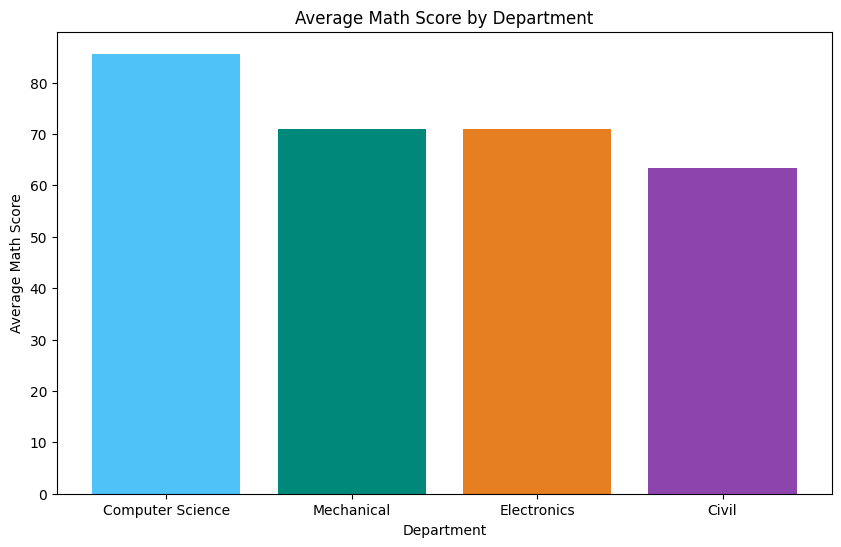

In [95]:
chart1_sql="""
SELECT department,ROUND(AVG(math_score),2) AS avg_math_score
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
chart1_df=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors = ['#4FC3F7','#00897B','#E67E22','#8E44AD']
ax.bar(chart1_df['department'],chart1_df['avg_math_score'],color=bar_colors)
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')
ax.set_title('Average Math Score by Department')

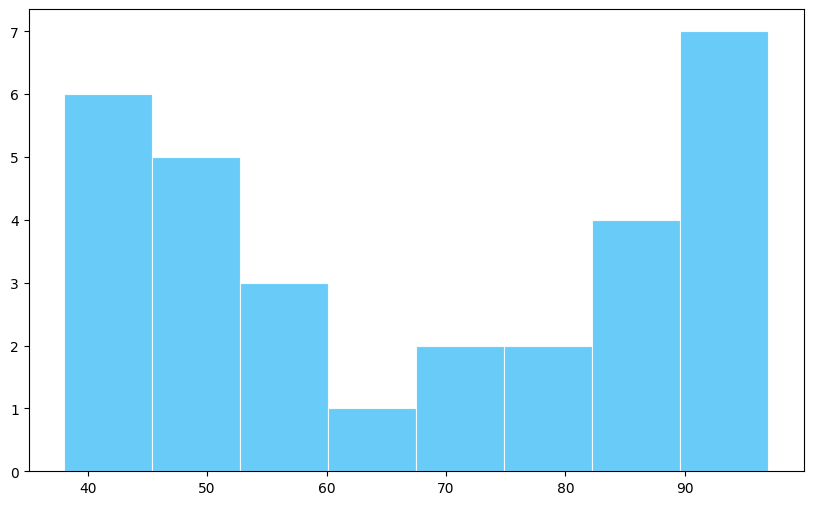

In [98]:
prog_scores = df['programming_score'].tolist()
fig, ax = plt.subplots(figsize=(10,6))
n, bins, patches = ax.hist(
    prog_scores,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)


In [100]:
mean_score = sum(prog_scores) / len(prog_scores)

ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='dashed',
    linewidth=2,
    label=f'Mean Score: {mean_score:.1f}'
)

ax.set_title(
    "Distribution of Programming Scores",
    fontsize=16,
    fontweight='bold'
)

display(df)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year,dept_code
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023,CS
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023,CS
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023,EC
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023,ME
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023,CS
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023,EC
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023,CE
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023,CS
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023,ME
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023,CS


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Sample dataset (replace with your own CSV)
df = pd.DataFrame({
    'Category': np.random.choice(['A', 'B', 'C', 'D'], 100),
    'Value': np.random.randint(10, 100, 100),
    'Score': np.random.randint(1, 10, 100)
})

df.head()

,Category,Value,Score
0,A,79,8
1,A,18,1
2,D,17,2
3,C,68,5
4,C,79,3


In [112]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [113]:
# Create database connection
conn = sqlite3.connect("student_dashboard.db")

cursor = conn.cursor()

print("Database connected successfully!")

Database connected successfully!


In [114]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS students (
    name TEXT,
    gender TEXT,
    department TEXT,
    math_score INTEGER,
    programming_score INTEGER,
    attendance_percentage REAL,
    total_score INTEGER
)
""")

conn.commit()

print("Table created successfully!")

Table created successfully!


In [115]:
students_data = [

    ("Arun Kumar", "Male", "Computer Science", 85, 90, 92, 175),
    ("Priya Sharma", "Female", "Electronics", 78, 88, 80, 166),
    ("Kavin Raj", "Male", "Computer Science", 95, 96, 98, 191),
    ("Divya Singh", "Female", "Civil", 67, 72, 70, 139),
    ("Rahul Verma", "Male", "Mechanical", 80, 75, 60, 155),
    ("Sneha Iyer", "Female", "Computer Science", 92, 94, 96, 186),
    ("Ajay Kumar", "Male", "Electronics", 88, 84, 82, 172),
    ("Meena Das", "Female", "Civil", 76, 81, 90, 157),
    ("Amit Bose", "Male", "Mechanical", 82, 86, 88, 168),
    ("Swati Kulkarni", "Female", "Computer Science", 90, 95, 93, 185),
    ("Arjun Nair", "Male", "Mechanical", 84, 88, 85, 172),
    ("Tanvi Mehta", "Female", "Electronics", 91, 89, 87, 180)

]

cursor.executemany("""
INSERT INTO students
VALUES (?, ?, ?, ?, ?, ?, ?)
""", students_data)

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [116]:
df = pd.read_sql_query(
    "SELECT * FROM students",
    conn
)

print(df.head())

           name  gender        department  math_score  programming_score  \
0    Arun Kumar    Male  Computer Science          85                 90   
1  Priya Sharma  Female       Electronics          78                 88   
2     Kavin Raj    Male  Computer Science          95                 96   
3   Divya Singh  Female             Civil          67                 72   
4   Rahul Verma    Male        Mechanical          80                 75   

   attendance_percentage  total_score  
0                   92.0          175  
1                   80.0          166  
2                   98.0          191  
3                   70.0          139  
4                   60.0          155  


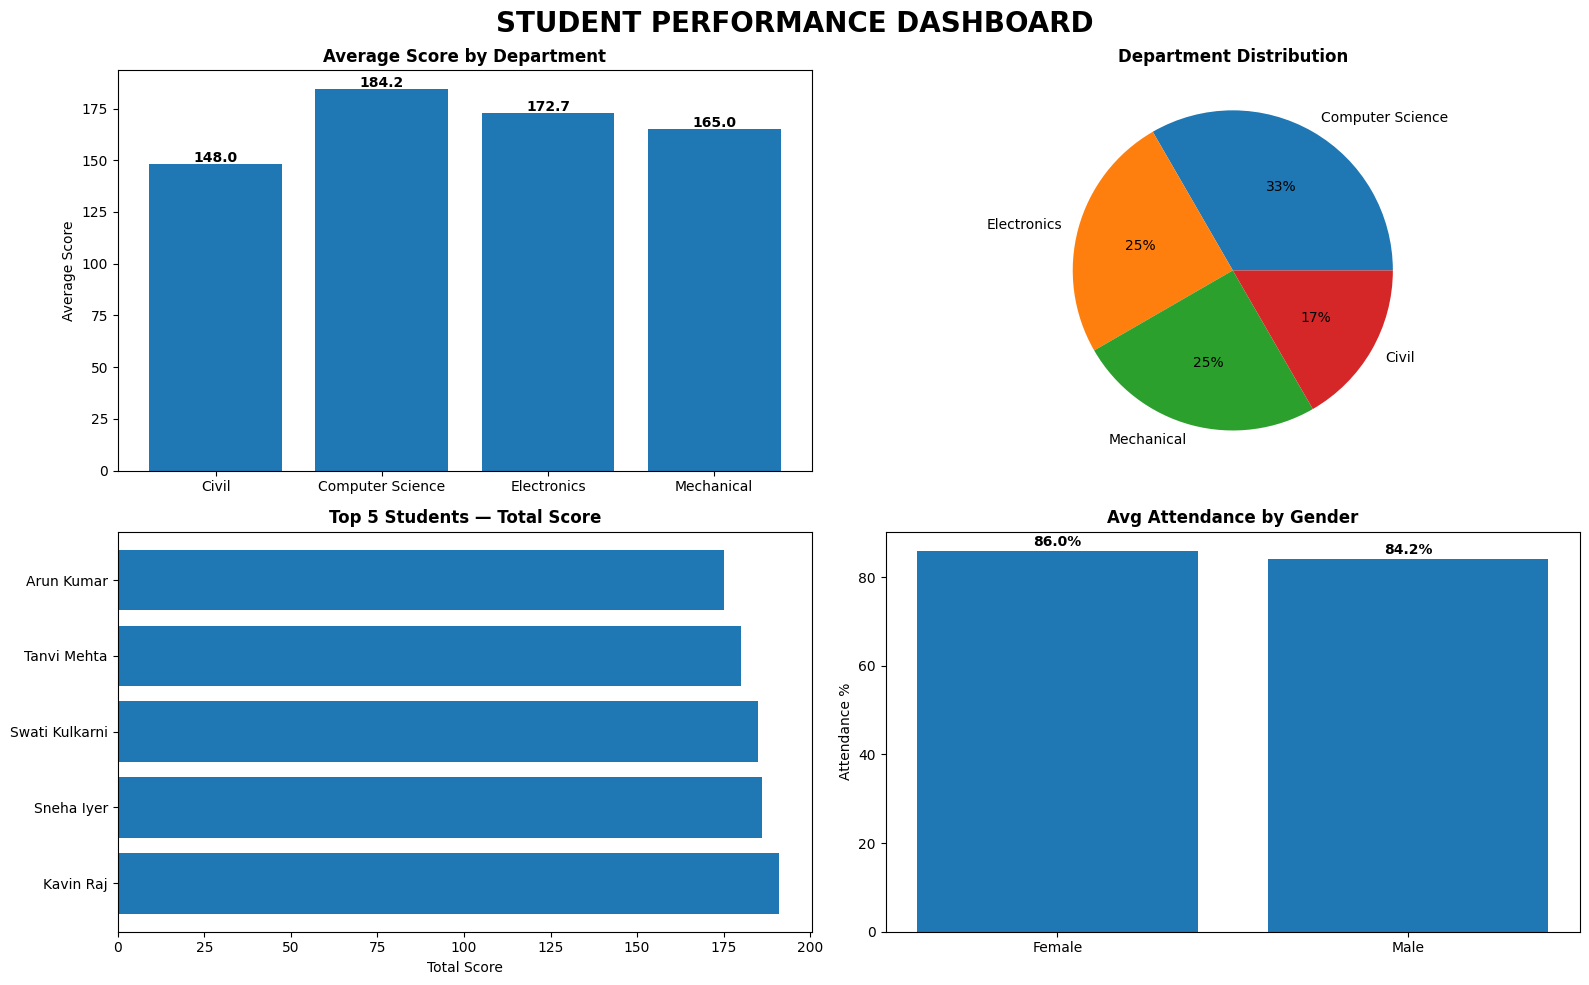

In [117]:
# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# =========================================
# CHART 1 — AVG SCORE BY DEPARTMENT
# =========================================

dept_avg = df.groupby("department")[
    "total_score"
].mean()

axes[0,0].bar(
    dept_avg.index,
    dept_avg.values
)

axes[0,0].set_title(
    "Average Score by Department",
    fontweight="bold"
)

axes[0,0].set_ylabel("Average Score")

# Add value labels
for i, value in enumerate(dept_avg.values):
    axes[0,0].text(
        i,
        value + 1,
        f"{value:.1f}",
        ha='center',
        fontweight='bold'
    )

# =========================================
# CHART 2 — DEPARTMENT DISTRIBUTION
# =========================================

dept_count = df["department"].value_counts()

axes[0,1].pie(
    dept_count.values,
    labels=dept_count.index,
    autopct='%1.0f%%'
)

axes[0,1].set_title(
    "Department Distribution",
    fontweight="bold"
)

# =========================================
# CHART 3 — TOP 5 STUDENTS
# =========================================

top_students = df.sort_values(
    by="total_score",
    ascending=False
).head(5)

axes[1,0].barh(
    top_students["name"],
    top_students["total_score"]
)

axes[1,0].set_title(
    "Top 5 Students — Total Score",
    fontweight="bold"
)

axes[1,0].set_xlabel("Total Score")

# =========================================
# CHART 4 — AVG ATTENDANCE BY GENDER
# =========================================

gender_attendance = df.groupby("gender")[
    "attendance_percentage"
].mean()

axes[1,1].bar(
    gender_attendance.index,
    gender_attendance.values
)

axes[1,1].set_title(
    "Avg Attendance by Gender",
    fontweight="bold"
)

axes[1,1].set_ylabel("Attendance %")

# Add labels
for i, value in enumerate(gender_attendance.values):
    axes[1,1].text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha='center',
        fontweight='bold'
    )

# =========================================
# DASHBOARD TITLE
# =========================================

plt.suptitle(
    "STUDENT PERFORMANCE DASHBOARD",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [118]:
conn.close()

print("Database connection closed!")

Database connection closed!


In [119]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [120]:
conn = sqlite3.connect("student_dashboard.db")

cursor = conn.cursor()

print("Database connected successfully!")

Database connected successfully!


In [121]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS students (

    name TEXT,
    gender TEXT,
    department TEXT,
    math_score INTEGER,
    programming_score INTEGER,
    attendance_percentage REAL,
    total_score INTEGER

)
""")

conn.commit()

print("Table created successfully!")

Table created successfully!


In [122]:
students_data = [

    ("Arun Kumar", "Male", "Computer Science", 85, 90, 92, 175),
    ("Priya Sharma", "Female", "Electronics", 78, 88, 80, 166),
    ("Kavin Raj", "Male", "Computer Science", 95, 96, 98, 191),
    ("Divya Singh", "Female", "Civil", 67, 72, 70, 139),
    ("Rahul Verma", "Male", "Mechanical", 80, 75, 60, 155),
    ("Sneha Iyer", "Female", "Computer Science", 92, 94, 96, 186)

]

cursor.executemany("""
INSERT INTO students
VALUES (?, ?, ?, ?, ?, ?, ?)
""", students_data)

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [123]:
df = pd.read_sql_query(
    "SELECT * FROM students",
    conn
)

print(df)

              name  gender        department  math_score  programming_score  \
0       Arun Kumar    Male  Computer Science          85                 90   
1     Priya Sharma  Female       Electronics          78                 88   
2        Kavin Raj    Male  Computer Science          95                 96   
3      Divya Singh  Female             Civil          67                 72   
4      Rahul Verma    Male        Mechanical          80                 75   
5       Sneha Iyer  Female  Computer Science          92                 94   
6       Ajay Kumar    Male       Electronics          88                 84   
7        Meena Das  Female             Civil          76                 81   
8        Amit Bose    Male        Mechanical          82                 86   
9   Swati Kulkarni  Female  Computer Science          90                 95   
10      Arjun Nair    Male        Mechanical          84                 88   
11     Tanvi Mehta  Female       Electronics        

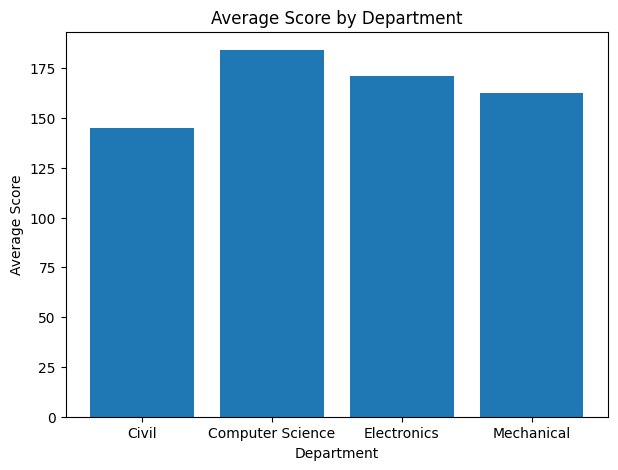

In [124]:
dept_avg = df.groupby("department")[
    "total_score"
].mean()

plt.figure(figsize=(7,5))

plt.bar(
    dept_avg.index,
    dept_avg.values
)

plt.title("Average Score by Department")

plt.xlabel("Department")

plt.ylabel("Average Score")

plt.show()

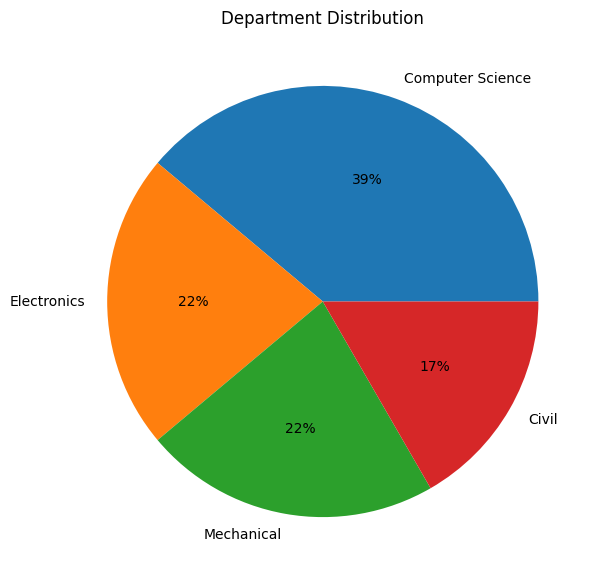

In [125]:
dept_count = df["department"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    dept_count.values,
    labels=dept_count.index,
    autopct='%1.0f%%'
)

plt.title("Department Distribution")

plt.show()

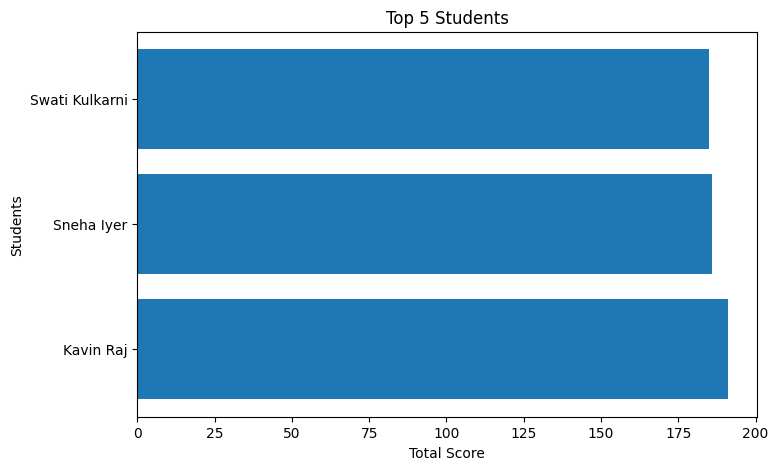

In [126]:
top_students = df.sort_values(
    by="total_score",
    ascending=False
).head(5)

plt.figure(figsize=(8,5))

plt.barh(
    top_students["name"],
    top_students["total_score"]
)

plt.title("Top 5 Students")

plt.xlabel("Total Score")

plt.ylabel("Students")

plt.show()

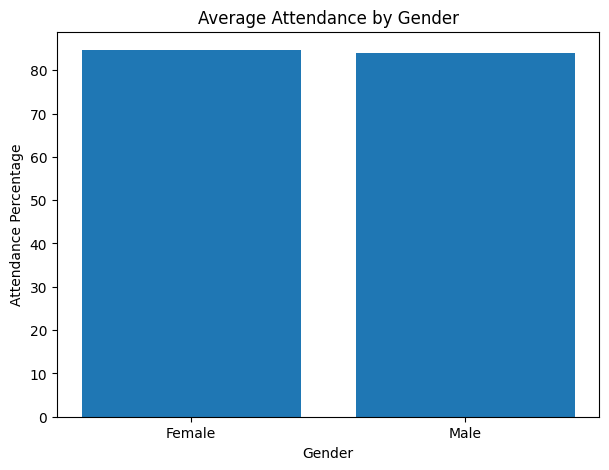

In [127]:
gender_attendance = df.groupby("gender")[
    "attendance_percentage"
].mean()

plt.figure(figsize=(7,5))

plt.bar(
    gender_attendance.index,
    gender_attendance.values
)

plt.title("Average Attendance by Gender")

plt.xlabel("Gender")

plt.ylabel("Attendance Percentage")

plt.show()

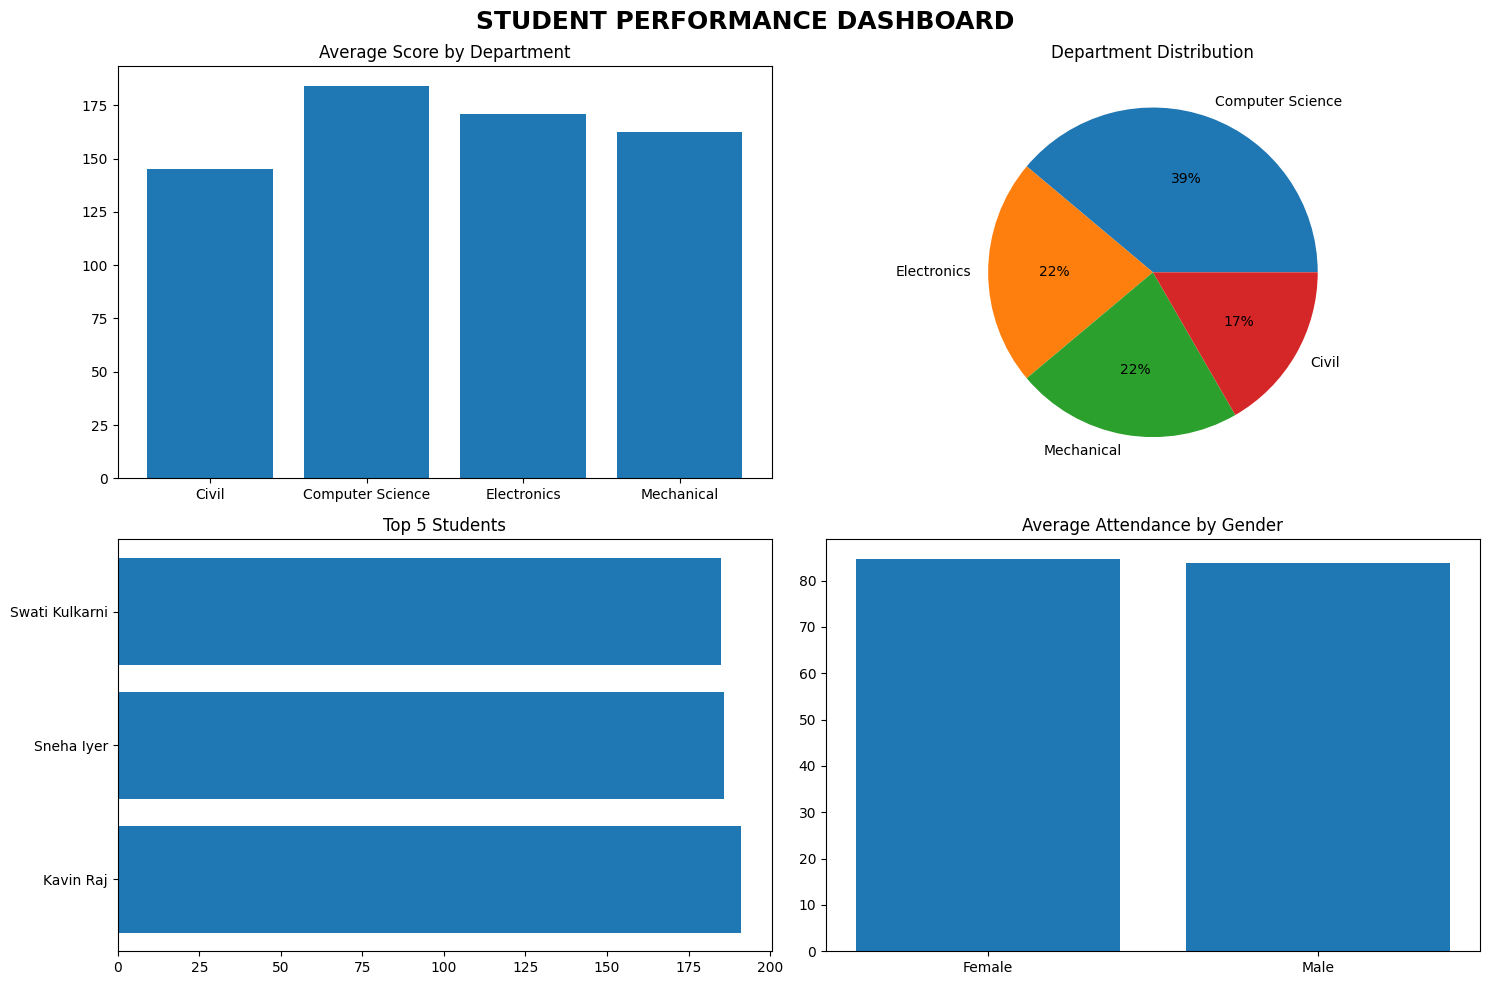

In [128]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# =====================================
# CHART 1
# =====================================

axes[0,0].bar(
    dept_avg.index,
    dept_avg.values
)

axes[0,0].set_title(
    "Average Score by Department"
)

# =====================================
# CHART 2
# =====================================

axes[0,1].pie(
    dept_count.values,
    labels=dept_count.index,
    autopct='%1.0f%%'
)

axes[0,1].set_title(
    "Department Distribution"
)

# =====================================
# CHART 3
# =====================================

axes[1,0].barh(
    top_students["name"],
    top_students["total_score"]
)

axes[1,0].set_title(
    "Top 5 Students"
)

# =====================================
# CHART 4
# =====================================

axes[1,1].bar(
    gender_attendance.index,
    gender_attendance.values
)

axes[1,1].set_title(
    "Average Attendance by Gender"
)

# =====================================
# MAIN TITLE
# =====================================

plt.suptitle(
    "STUDENT PERFORMANCE DASHBOARD",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

In [129]:
conn.close()

print("Project Completed Successfully!")

Project Completed Successfully!


In [132]:
import sqlite3

conn = sqlite3.connect('college.db')
cursor = conn.cursor()
query1 = """
SELECT
    ROUND(AVG(programming_score), 2) AS avg_programming_score
FROM students
WHERE gender='Female';
"""

result1 = run_query(query1, "Average Programming Score for Female Students")



Average Programming Score for Female Students
 avg_programming_score
                  70.2


In [133]:
query2 = """
SELECT *
FROM students
WHERE attendance_percentage > 85;
"""

result2 = run_query(query2, "WHERE Example")


WHERE Example
 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage       city  admission_year dept_code
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92     Mumbai            2023        CS
       1002    Priya Patel   20 Female Computer Science         2          76             82             88                 79                     87  Ahmedabad            2023        CS
       1004    Sneha Reddy   20 Female       Mechanical         2          70             80             75                 48                     95  Hyderabad            2023        ME
       1005     Arjun Nair   19   Male Computer Science         2          92             88             81                 95                     90      Kochi            2023        CS
       1008    Divya Singh   19 Female Computer Sc

In [134]:
query3 = """
SELECT department,
AVG(math_score) AS avg_math
FROM students
GROUP BY department
HAVING AVG(math_score) > 70;
"""

result3 = run_query(query3, "HAVING Example")


HAVING Example
      department  avg_math
Computer Science 85.615385
     Electronics 71.000000
      Mechanical 71.000000


In [135]:
query4 = """
SELECT
    department,
    ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""

result4 = run_query(query4, "Departments with Attendance Above 85%")


Departments with Attendance Above 85%
      department  avg_attendance
Computer Science           90.69


In [136]:
result = pd.read_sql_query(
    "SELECT * FROM students",
    conn
)

print(result)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta   19  Female             Civil         2   
12        1013      Sures

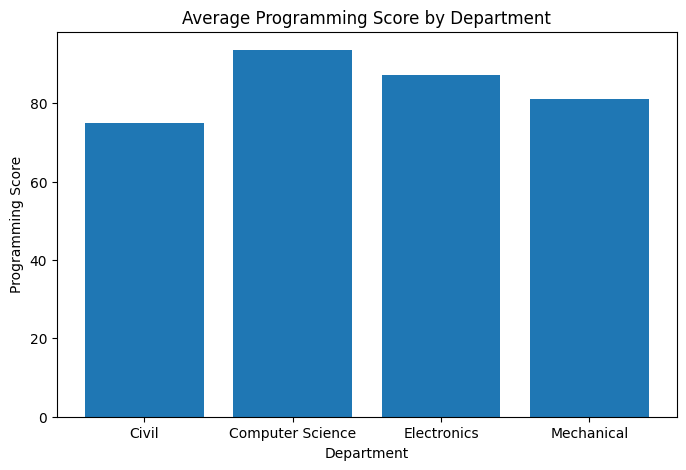

In [137]:
program_scores = df.groupby('department')['programming_score'].mean()

plt.figure(figsize=(8,5))

plt.bar(
    program_scores.index,
    program_scores.values
)

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Programming Score")

plt.show()